# Informe Trabajo Practico de Laboratorio 1

## Teoría de Circuitos II

## Alumno
### Juan Manuel Miranda Del Valle

## Institución
### Universidad Tecnologica Nacional

## Profesores
### Mariano Llamedo Soria y César Fouco

### Consigna:

##### Diseñar un filtro Notch activo a 50hz con ancho de banda de 10hz a 3db.
##### Implementar con un Ackerberg-Mosberg.



#### 1. Obtener el orden del filtro y hallar la función transferencia total

<div align="center">
    <img src="1.png" width="800">
</div>

Como la consigna no pide requerimientos de atenuación mínima no teníamos ninguna limitación de un orden mínimo de filtro a usar, por lo que decidimos hacerlo de orden 2

#### 2. Obtener la transferencia de la red circuital a implementar. 

El circuito a implementar es el siguiente

<div align="center">
    <img src="2.png" width="800">
</div>

Y obtuvimos la transferencia de la siguiente forma: 



<div align="center">
    <img src="3.png" width="800">
</div>

Luego obtuvimos los valores de los componentes

<div align="center">
    <img src="4.png" width="800">
</div>

##### Entonces los componentes que elegimos para hacer el circuito

$ R1=R2= 160k\Omega $

$ R3=$ Resistencia variable hasta $50k\Omega$ medida con el multimetro antes de poner en el circuito a $ 31,83k\Omega$

El resto de las resistencias son de $ 10k\Omega $ 

Los capacitores de $ 100nF$


#### Simulación numérica/simbólica de la función transferencia en Python. 

In [7]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import scipy.signal as signal
import math as mt
# Librerías externas NumPy, SciPy y Matplotlib


# ============================================================
# 1. SIMULACIÓN SIMBÓLICA
# ============================================================

s = sp.symbols('s')
R1, R2, R3, C = sp.symbols('R1 R2 R3 C', positive=True)

# Relaciones obtenidas para el circuito
w0 = 1 / (R3*C)
Q = R2 / R3
K = R3 / R1

T = (s**2 + w0**2) / (s**2 + (w0/Q)*s + w0**2)

print("Función transferencia simbólica de -Vo/Vi:")
display(sp.Eq(-sp.Symbol("V_o") / sp.Symbol("V_i"), sp.simplify(G)))

# Forma expresada directamente mediante los componentes
T_componentes = sp.simplify(T)

print("Función transferencia en función de R2, R3 y C:")
display(sp.Eq(
    sp.Symbol("T(s)"),
    T_componentes
))


Función transferencia simbólica de -Vo/Vi:


Eq(-V_o/V_i, R2*(C**2*R3**2*s**2 + 1)/(C**2*R2*R3**2*s**2 + C*R3**2*s + R2))

Función transferencia en función de R2, R3 y C:


Eq(T(s), R2*(C**2*R3**2*s**2 + 1)/(C**2*R2*R3**2*s**2 + C*R3**2*s + R2))

In [5]:
# 2. VALORES REALES DE LOS COMPONENTES

R1_val = 160e3       # ohm
R2_val = 160e3       # ohm
R3_val = 31.83e3     # ohm
C_val  = 100e-9      # farad

w0_val = 1 / (R3_val*C_val)
f0_val = w0_val / (2*np.pi)
Q_val = R2_val / R3_val
K_val = R3_val / R1_val

print(f"ω0 = {w0_val:.3f} rad/s")
print(f"f0 = {f0_val:.3f} Hz")
print(f"Q  = {Q_val:.4f}")
print(f"K  = {K_val:.4f}")
print(f"1/Q = {1/Q_val:.4f}")

# 3. FUNCIÓN TRANSFERENCIA NUMÉRICA

# T(s) representa -Vo/Vi
numerador = [1, 0, w0_val**2]
denominador = [1, w0_val/Q_val, w0_val**2]

print("\nNumerador:", numerador)
print("Denominador:", denominador)

ceros = np.roots(numerador)
polos = np.roots(denominador)

print("\nCeros:")
print(ceros)

print("\nPolos:")
print(polos)

ω0 = 314.169 rad/s
f0 = 50.002 Hz
Q  = 5.0267
K  = 0.1989
1/Q = 0.1989

Numerador: [1, 0, 98702.17497151702]
Denominador: [1, 62.5, 98702.17497151702]

Ceros:
[-0.+314.16902293j  0.-314.16902293j]

Polos:
[-31.25+312.61096025j -31.25-312.61096025j]


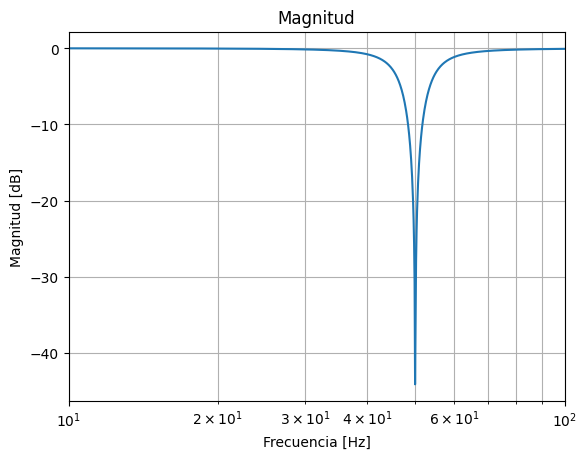

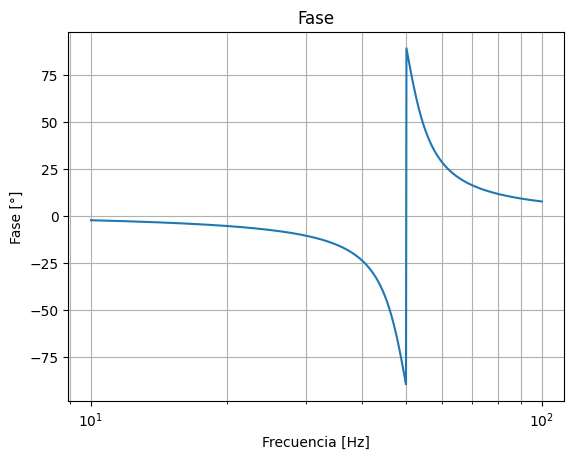

In [8]:
num = [1,0, (100*np.pi)**2]
den = [1, 20*np.pi, (100*np.pi)**2]

my_tf = signal.TransferFunction(num, den)
w = np.logspace(1, 2, 1000) * 2*np.pi
w, mag, phase = signal.bode(my_tf,w)

f = w/(2*np.pi)
plt.figure()
plt.semilogx(f, mag)
plt.xlim(10,100)
plt.title("Magnitud")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")

plt.grid(True, which="both")

plt.figure()
plt.semilogx(f, phase)
plt.title("Fase")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [°]")
plt.grid(True, which="both")

plt.show()

#### 4.Simulación circuital. Incluya el modelo real del OPAMP. 

##### Fue un desafio encontrar el modelo del OpAmp a usar dado que el fabricante da el modelo para PSpice, pero despues de un rato largo de busqueda se logro dar con el modelo indicado para el LTSpice. Vale aclarar que el modelo puesto en la simulacion es el modelo del OpAmp que viene solo en un integrado por eso el nombre en la simulacion es el TL081. Pero como usamos 4 de esos en la placa nosotros pusimos un TL084, que es el integrado que trae 4 OpAmp con las mismas caracteristicas que el TL081

<div align="center">
    <img src="2.png" width="800">
</div>

<div align="center">
    <img src="5.png" width="1000">
</div>

### Implementacion y armado

#### En el altium implementamos el circuito planteado e hicimos el Layout

<div align="center">
    <img src="6.png" width="1000">
</div>

<div align="center">
    <img src="7.png" width="1000">
</div>

Luego hicimos la placa con la CNC de la facultad, tuvimos varios problemas y tuvimos que hacerla 2 veces.

Inicialmente nos habiamos equivocado en el esquematico del Altium y  arrastramos ese error al layout, entrada inversora y no inversora de uno de los opamps conectadas entre si y a GND, este error hacia que a la salida vieramos la entrada. Tuvimos que hacer un puente y cortar una pista, afortunadamente no tuvimos que hacer una tercera vez la placa.

Una vez solucionado eso seguia sin funcionar correctamente por lo que haciendo una revision mas descubrimos un corto que solucionamos rapidamente, y finalmente logramos que funcione.

Cabe destacar que usamos resistores SMD con tolerancia del 1%, los capacitores de 100nF tambien son SMD.
Usamos conectores Bnc para facilitar la conexion a la hora de la practica en el laboratorio.

Adjunto fotos de la placa finalizada: 

<div align="center">
    <img src="8.jpeg" width="1000">
</div>

<div align="center">
    <img src="9.jpeg" width="1000">
</div>

### Barrido en Frecuencia con el Osciloscopio

In [8]:
import pandas as pd

tabla = pd.read_clipboard(decimal=",")

display(
    tabla.style
    .format({
        "Frecuencia [Hz]": "{:.2f}",
        "Vout [mV]": "{:.0f}",
        "Vout [dB]": "{:.2f}"
    })
    .hide(axis="index")
    .set_caption("Barrido experimental en frecuencia")
)

Frecuencia [Hz],Vout [mV],Vout [dB],Delta T [mS],Fase [rad],Retardo [mS]
10.00,1000,0.00,1.200000,-0.075398,0.400000
20.00,1000,0.00,0.800000,-0.100531,1.400000
30.00,980,-0.18,1.000000,-0.188496,3.800000
40.00,980,-0.18,1.700000,-0.427257,9.800000
45.00,760,-2.38,2.600000,-0.735133,16.700000
47.00,580,-4.73,3.200000,-0.944991,3.200000
47.65,500,-6.02,3.200000,-0.958060,3.200000
48.00,400,-7.96,3.200000,-0.965097,22.800000
49.00,250,-12.04,3.600000,-1.108354,43.000000
49.25,210,-13.56,3.800000,-1.175898,-127.933333


#### Grafico de los puntos medidos 

Ademas uno los puntos con rectas

Frecuencia de mínimo: 50.40 Hz
Ganancia mínima: -24.44 dB


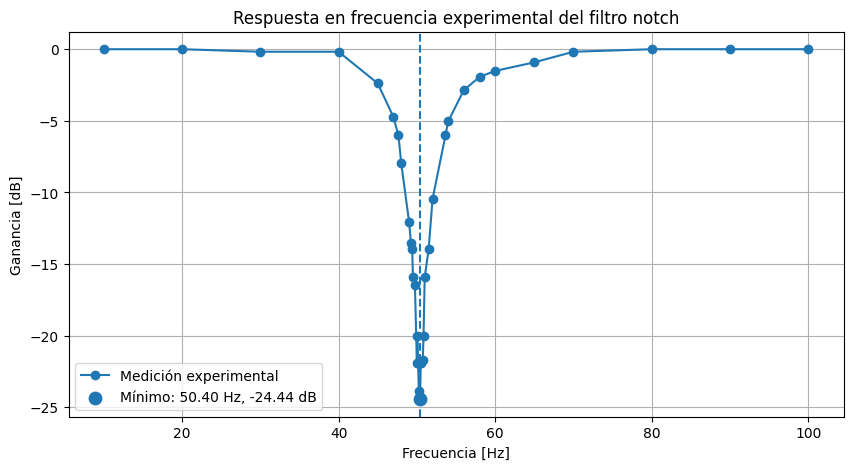

In [2]:
import matplotlib.pyplot as plt

# Ordenar la tabla por frecuencia
tabla = tabla.sort_values("Frecuencia [Hz]")

# Buscar el punto de menor ganancia
indice_minimo = tabla["Vout [dB]"].idxmin()

f_min = tabla.loc[indice_minimo, "Frecuencia [Hz]"]
db_min = tabla.loc[indice_minimo, "Vout [dB]"]

print(f"Frecuencia de mínimo: {f_min:.2f} Hz")
print(f"Ganancia mínima: {db_min:.2f} dB")

# Gráfico
plt.figure(figsize=(10, 5))

plt.plot(
    tabla["Frecuencia [Hz]"],
    tabla["Vout [dB]"],
    marker="o",
    linestyle="-",
    label="Medición experimental"
)

plt.scatter(
    f_min,
    db_min,
    s=80,
    label=f"Mínimo: {f_min:.2f} Hz, {db_min:.2f} dB"
)

plt.axvline(f_min, linestyle="--")

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dB]")
plt.title("Respuesta en frecuencia experimental del filtro notch")
plt.grid(True)
plt.legend()
plt.show()

#### Uso una interpolacion de PCHIP para unir los puntos por lo que hace que quede una curva mas suave.

La PCHIP es una interpolacion que usa polinomios de distintos grados para unir punto a punto sin cambios abruptos

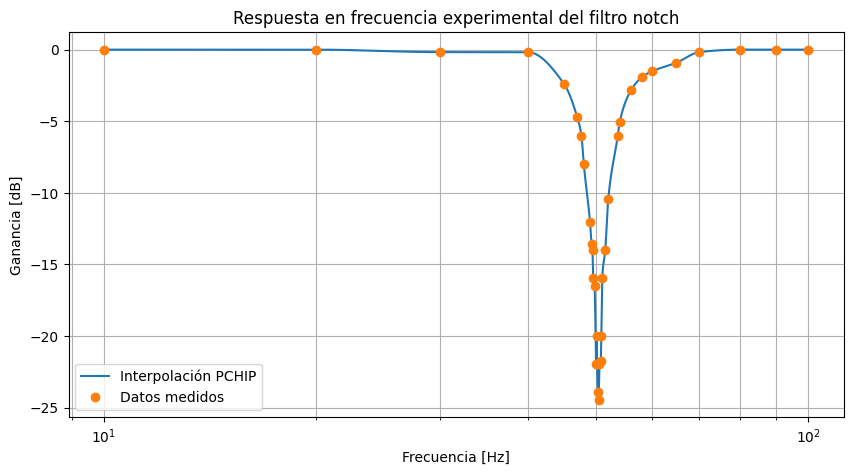

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Ordenar los datos
tabla = tabla.sort_values("Frecuencia [Hz]")

f = tabla["Frecuencia [Hz]"].to_numpy()
ganancia_db = tabla["Vout [dB]"].to_numpy()

# Trabajamos con log(f) porque es una respuesta en frecuencia
log_f = np.log10(f)

# Interpolación suave
interpolador = PchipInterpolator(log_f, ganancia_db)

# Muchos puntos para dibujar la curva
f_suave = np.logspace(
    np.log10(f.min()),
    np.log10(f.max()),
    1000
)

ganancia_suave = interpolador(np.log10(f_suave))

# Gráfico
plt.figure(figsize=(10, 5))

plt.semilogx(
    f_suave,
    ganancia_suave,
    label="Interpolación PCHIP"
)

plt.semilogx(
    f,
    ganancia_db,
    "o",
    label="Datos medidos"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dB]")
plt.title("Respuesta en frecuencia experimental del filtro notch")
plt.grid(True, which="both")
plt.legend()
plt.show()

#### Grafico de Fase

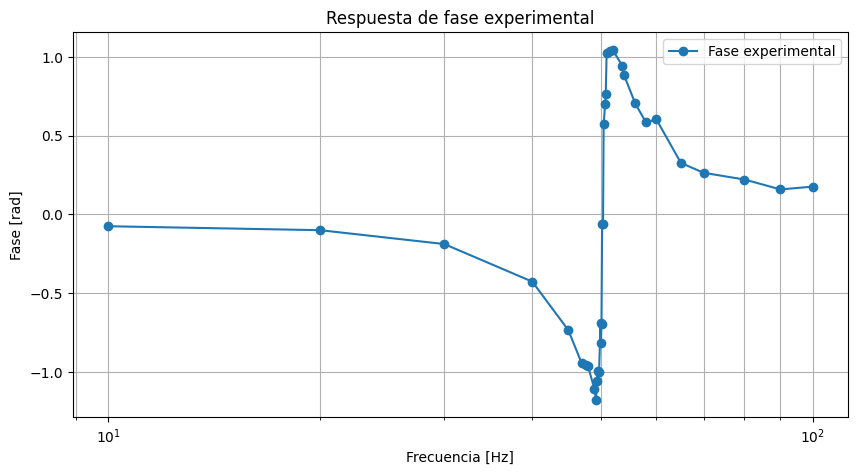

In [6]:
# GRÁFICO DE FASE
datos_fase = tabla.dropna(
    subset=["Frecuencia [Hz]", "Fase [rad]"]
)

plt.figure(figsize=(10, 5))

plt.semilogx(
    datos_fase["Frecuencia [Hz]"],
    datos_fase["Fase [rad]"],
    marker="o",
    linestyle="-",
    label="Fase experimental"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.title("Respuesta de fase experimental")
plt.grid(True, which="both")
plt.legend()
plt.show()

#### Grafico de Retardo de grupo

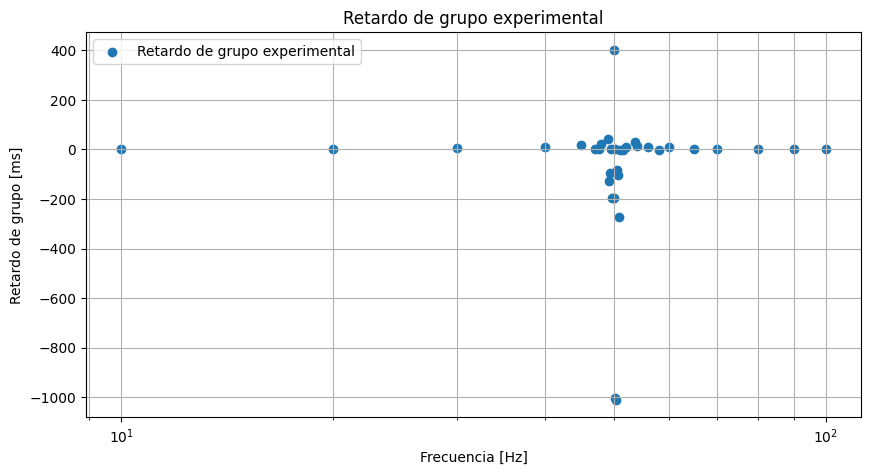

In [10]:

datos_retardo = tabla.dropna(
    subset=["Frecuencia [Hz]", "Retardo [mS]"]
)

plt.figure(figsize=(10, 5))

plt.scatter(
    datos_retardo["Frecuencia [Hz]"],
    datos_retardo["Retardo [mS]"],
    label="Retardo de grupo experimental"
)

plt.xscale("log")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Retardo de grupo [ms]")
plt.title("Retardo de grupo experimental")
plt.grid(True, which="both")
plt.legend()
plt.show()